# Animating the colorbar in matplotlib

This has been tricky.

0.0 7.282933578371178
0.0 8.28268184956277
0.0 9.282430120754364
0.0 10.282178391945957
0.0 11.281926663137549
0.0 12.281674934329143
0.0 13.281423205520735
0.0 14.281171476712327
0.0 15.28091974790392


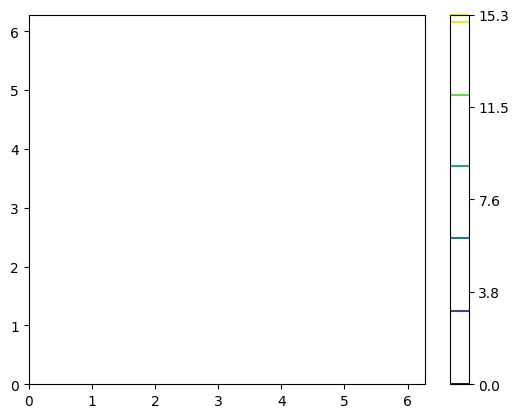

In [158]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create some data
x = np.linspace(0, 2 * np.pi, 100)
y = np.linspace(0, 2 * np.pi, 100)
X, Y = np.meshgrid(x,y)
levels = 5

# Create a figure and axis
fig, ax = plt.subplots()
Z = X + np.sin(Y)**2
sc = ax.contour(X, Y, Z, levels, cmap='viridis')

# Add a colorbar
colorbar = plt.colorbar(sc)
# colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), levels-1),1)
# sc.set_array(Z.flatten())
# colorbar.update_normal(sc)

ims = []
ims.append([sc])

# Function to update the scatter plot and colorbar
def update(frame):
    # ax.clear()
    Z = X + 1*frame * np.sin(Y)**2
    sc = ax.contour(X, Y, Z, levels, cmap='viridis', vmin=np.min(Z), vmax=np.max(Z))
    # sc.set_array(Z.flatten())
    print(np.min(Z), np.max(Z))
    colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), levels),1)
    colorbar.update_normal(sc)
    # colorbar.mappable = sc
    colorbar.set_ticks(np.round(np.linspace(np.min(Z), np.max(Z), levels),1))
    ims.append([sc])
    
nframes = 10
for frame in range(1, nframes):
    update(frame)
# Create animation
# ani = animation.FuncAnimation(fig, update, frames=10, interval=50)
ani = animation.ArtistAnimation(fig, ims)
# ims[0]
# plt.show()

In [159]:
animation.ArtistAnimation?

Init signature: animation.ArtistAnimation(fig, artists, *args, **kwargs)
Docstring:     
`TimedAnimation` subclass that creates an animation by using a fixed
set of `.Artist` objects.

Before creating an instance, all plotting should have taken place
and the relevant artists saved.

.. note::

    You must store the created Animation in a variable that lives as long
    as the animation should run. Otherwise, the Animation object will be
    garbage-collected and the animation stops.

Parameters
----------
fig : `~matplotlib.figure.Figure`
    The figure object used to get needed events, such as draw or resize.
artists : list
    Each list entry is a collection of `.Artist` objects that are made
    visible on the corresponding frame.  Other artists are made invisible.
interval : int, default: 200
    Delay between frames in milliseconds.
repeat_delay : int, default: 0
    The delay in milliseconds between consecutive animation runs, if
    *repeat* is True.
repeat : bool, default: Tru

In [160]:
ani.save('test.mp4', fps=10)


grabbing frame  1
Saving figure with filename  <_io.BufferedWriter name=65> and format  rgba
Figure saved, time elapsed:  0.03057408332824707
frame grabbed, elapsed time: 0.030863523483276367
grabbing frame  2
Saving figure with filename  <_io.BufferedWriter name=65> and format  rgba
Figure saved, time elapsed:  0.025378704071044922
frame grabbed, elapsed time: 0.025627613067626953
grabbing frame  3
Saving figure with filename  <_io.BufferedWriter name=65> and format  rgba
Figure saved, time elapsed:  0.024005413055419922
frame grabbed, elapsed time: 0.024199485778808594
grabbing frame  4
Saving figure with filename  <_io.BufferedWriter name=65> and format  rgba
Figure saved, time elapsed:  0.023667573928833008
frame grabbed, elapsed time: 0.023853540420532227
grabbing frame  5
Saving figure with filename  <_io.BufferedWriter name=65> and format  rgba
Figure saved, time elapsed:  0.026256322860717773
frame grabbed, elapsed time: 0.026478290557861328
grabbing frame  6
Saving figure with

In [161]:
from IPython.display import HTML

HTML("""
<video controls id="theVideo2">
        <source src="test.mp4">
</video>

<script>
video2 = document.getElementById("theVideo2")
video2.width = 800;
video2.playbackRate = .6;
video2.loop = true;
</script>
""")


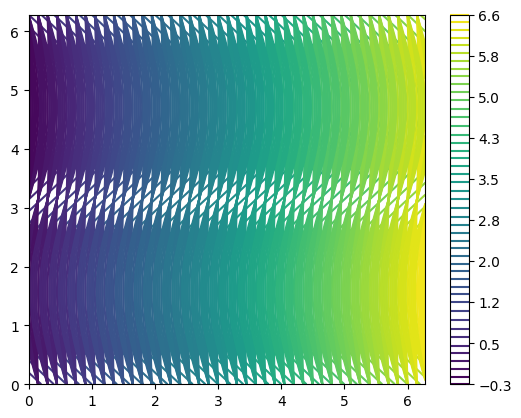

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera

# Create some data
x = np.linspace(0, 2 * np.pi, 100)
y = np.linspace(0, 2 * np.pi, 100)
X, Y = np.meshgrid(x,y)

# Create a figure and axis
fig, ax = plt.subplots()
camera = Camera(fig)

Z = X + np.sin(Y)
sc = ax.contour(X, Y, Z, levels=50, cmap='viridis')

# Add a colorbar
colorbar = plt.colorbar(sc)
colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), 10),1)

frames = 10
for fr in range(1, frames):
    # ax.clear()
    Z = X + .03*fr * np.sin(Y)
    sc = ax.contour(X, Y, Z, levels=50, cmap='viridis')
    # sc.set_array(Z.flatten())
    colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), 10),1)
    colorbar.update_normal(sc)
    camera.snap()
    

In [20]:
animation = camera.animate()
plt.show()
animation.save('ctest.mp4', fps=20)

AttributeError: 'NoneType' object has no attribute 'canvas'

In [ ]:
animation._

In [30]:
from IPython.display import HTML

HTML("""
<video controls id="theVideo2">
        <source src="tt.mp4">
</video>
z
<script>
video2 = document.getElementById("theVideo2")
video2.width = 800;
video2.playbackRate = .6;
video2.loop = true;
</script>
""")

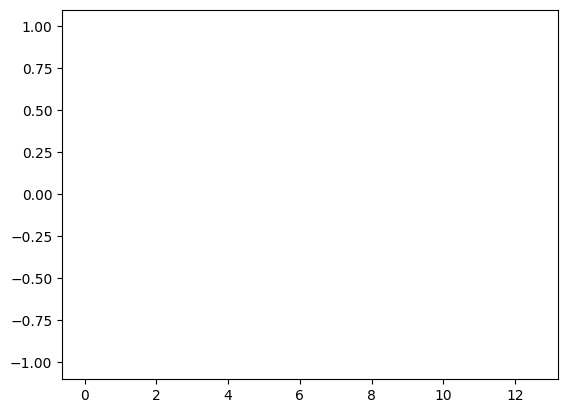

In [38]:
# Create figure and axis
fig, ax = plt.subplots()
frames = []

# Pre-render frames
for i in range(10):
    x = np.linspace(0, 4 * np.pi, 100)
    y = np.sin(x + i * 0.2)
    frame, = ax.plot(x, y, 'b')
    frames.append([frame])

# Create animation
ani = animation.ArtistAnimation(fig, frames, interval=200, blit=True)

In [29]:
ani.save('tt.mp4')

grabbing frame  1
Saving figure with filename  <_io.BufferedWriter name=66> and format  rgba
Figure saved, time elapsed:  0.022891759872436523
frame grabbed, elapsed time: 0.02322077751159668
grabbing frame  2
Saving figure with filename  <_io.BufferedWriter name=66> and format  rgba
Figure saved, time elapsed:  0.019275426864624023
frame grabbed, elapsed time: 0.019476652145385742
grabbing frame  3
Saving figure with filename  <_io.BufferedWriter name=66> and format  rgba
Figure saved, time elapsed:  0.02344202995300293
frame grabbed, elapsed time: 0.02388477325439453
grabbing frame  4
Saving figure with filename  <_io.BufferedWriter name=66> and format  rgba
Figure saved, time elapsed:  0.019341468811035156
frame grabbed, elapsed time: 0.01953434944152832
grabbing frame  5
Saving figure with filename  <_io.BufferedWriter name=66> and format  rgba
Figure saved, time elapsed:  0.018662452697753906
frame grabbed, elapsed time: 0.0188596248626709
grabbing frame  6
Saving figure with file